# Evaluación 1

Integrante 1: Lukas Lagos

Integrante 2: Fernanda Fernandez

Integrante 3: Sebastian Soriano

Integrante 4: Benjamin Gajardo

Correo Electrónico Integrante 1: lukas.lagos2301@alumnos.ubiobio.cl

Correo Electrónico Integrante 2: fernanda.fernandez2301@alumnos.ubiobio.cl

Correo Electrónico Integrante 3: sebastian.soriano2301@alumnos.ubiobio.cl

Correo Electrónico Integrante 4: benjamin.gajardo2301@alumnos.ubiobio.cl

Fecha de Creación: 30 Agosto de 2026
Versión: 1.0

<hr>

## Descripción
Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.

<hr>

## Carga de datos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

In [2]:
!wget https://raw.githubusercontent.com/SebaSoriano/E1-EDA/refs/heads/main/rendimiento_academico_evaluacion.csv

--2026-09-04 15:21:52--  https://raw.githubusercontent.com/SebaSoriano/E1-EDA/refs/heads/main/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv.14’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.05s   

2026-09-04 15:21:53 (7.51 MB/s) - ‘rendimiento_academico_evaluacion.csv.14’ saved [382638/382638]



# Metadata

_Descripción de las columnas del set de datos de la evaluación 1._

---

| Variable               | Rol           | Tipo       | Descripción                      |
| ---------------------- | ------------- | ---------- | -------------------------------- |
| `StudentID`            | Identificador | Categórica | Identificador del estudiante     |
| `Age`                  | Feature       | Numérica   | Edad                             |
| `StudyHours`           | Feature       | Numérica   | Horas semanales de estudio       |
| `Attendance`           | Feature       | Numérica   | Porcentaje de asistencia         |
| `PreviousGPA`          | Feature       | Numérica   | Promedio académico previo (escala de 1 a 10)       |
| `AssignmentsCompleted` | Feature       | Numérica   | Porcentaje de tareas completadas |
| `SleepHours`           | Feature       | Numérica   | Horas de sueño diarias           |
| `InternetHours`        | Feature       | Numérica   | Horas diarias de uso de Internet |
| `Scholarship`          | Feature       | Categórica | Tenencia de beca                 |
| `Program`              | Feature       | Categórica | Programa académico               |
| `FinalGrade`           | Target        | Numérica   | Calificación final (escala de 1 a 10)               |




In [3]:
data = pd.read_csv("rendimiento_academico_evaluacion.csv")

# Diagnóstico de calidad de datos

## Caracterizacion del dataset

In [4]:
data.shape

(5100, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB



1. La cantidad de registros es de 5100 filas
2. La cantidad de variables son 11
3. Los tipos de datos son 8 float64 y 3 objetos
4. Las variablas numericas son:
- La edad **(Age)**
- Las horas de estudio **(StudyHours)**
- Asistencia a clases **(Attendance)**
- Promedio del periodo anterior **(PreviousGPA)**
- Tareas completadas **(AssignmentsCompleted)**
- Horas de sueño **(SleepHours)**
- Horas de internet **(InternetHours)**
- Nota final **(FinalGrade)**

las variables categoricas:
- Becados **(Scholarship)**
- Carreras universitarias **(Program)**

5.- La variable que le corresponde al identificador es **StudentID**

6.- La variable que corresponde al resultado academico es **FinalGrade**



## Valores faltantes

In [6]:
null_summary = pd.DataFrame(
    {
        "Nulos_EnTotal": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_EnTotal"] > 0])
print("\n")

                      Nulos_EnTotal  Porcentaje_Nulos
Age                             103              2.02
StudyHours                      181              3.55
Attendance                      224              4.39
PreviousGPA                     162              3.18
AssignmentsCompleted            216              4.24
SleepHours                      122              2.39
InternetHours                   176              3.45
Scholarship                      81              1.59
Program                          70              1.37




### Cantidad de valores faltantes por variable: 
- **Age:** 103 variables faltantes
- **StudyHours:** 181 valores faltantes
- **Attendance:** 224 valores faltantes
- **PreviousGPA:** 162 valores faltantes
- **AssignmentsCompleted:** 216 valores faltantes
- **SleepHours:** 122 valores faltantes
- **InternetHours:** 176 valores faltantes
- **Scholarship:** 81 valores faltantes
- **Program:** 70 valores faltantes

### Porcentaje de valores faltantes por variable: 
- **Age:** 2.02%
- **StudyHours:** 3.55%
- **Attendance:** 4.39%
- **PreviousGPA:** 3.18%
- **AssignmentsCompleted:** 4.24%
- **SleepHours:** 2.39%
- **InternetHours:** 3.45%
- **Scholarship:** 1.59%
- **Program:** 1.37%

Las variables **StudentID** y **FinalGrade** no presentan valores faltantes

Las variables que presentan una mayor cantidad de datos faltantes son: 
- Attendance con **224** datos faltantes
- AssignmentsCompleted con **216** datos faltantes

### Estrategia de tratamiento: 
- Se deben imputar todos estos valores faltantes ya que no es posible eliminar ninguna de estas variables debido a que el porcentaje de nulos es demasiado bajo y todas las variables son relevantes. Las medidas que tomaremos con las variables numericas continuas es imputar por la mediana y con las numericas discretas lo haremos con la moda


## Existencia de Duplicados

In [7]:
#Revisa la existencia de duplicados
total_duplicados = data.duplicated().sum()
print("El número total de registros duplicados es: ", total_duplicados)

El número total de registros duplicados es:  100


In [8]:
#Obtiene los registros duplicaciones
data[data.duplicated(keep=False)].sort_values(by='StudentID')

,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5017,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
4895,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
1437,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
3572,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
736,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78
...,...,...,...,...,...,...,...,...,...,...,...
254,STU-14882,27.0,19.92,97.09,7.00,100.00,6.65,3.69,No,Contador Auditor,5.05
3515,STU-14945,21.0,17.87,87.42,6.61,96.05,6.44,4.53,Sí,Ingeniería Industrial,4.55
437,STU-14945,21.0,17.87,87.42,6.61,96.05,6.44,4.53,Sí,Ingeniería Industrial,4.55
1003,STU-14951,26.0,7.30,83.61,4.74,100.00,9.10,3.21,No,Ingeniería Civil,4.29


- El dataset presenta un total de 100 registros duplicados, lo cual representa un 1.96% respecto del dataset
- La variable principal que podria utilizarse para identificar los registros duplicados es el **StudentID** ya que esta variable es unica para cada estudiante, por lo tanto, si encontramos dos o más estudiantes que tengan el mismo ID significa que están duplicados
Lo que haremos con los datos duplicados será eliminarlos ya que solo representan un 1.96% de todos los datos, son redundantes y además no aportan información nueva, al ser copias afectan directamente las estadisticas quedando estas sesgadas hacia esos valores

## Inconsistencias

### Inconsistencias Cuantitativas

In [9]:
regla_age = (data["Age"] < 16 ) | (data["Age"] > 120)
regla_StudyHours = (data["StudyHours"] < 0) | (data["StudyHours"] >= 168)
regla_attendance = (data["Attendance"] < 0) | (data["Attendance"] > 100)
regla_previousgpa = (data["PreviousGPA"] < 1) | (data["PreviousGPA"] > 10)
regla_assignmentscompleted = (data["AssignmentsCompleted"] < 0) | (data["AssignmentsCompleted"] > 100)
regla_sleephours = (data["SleepHours"] < 0) | (data["SleepHours"] >= 24)
regla_internethours = (data["InternetHours"] < 0) | (data["InternetHours"] >= 24)
regla_finalgrade = (data["FinalGrade"] < 1) | (data["FinalGrade"] > 10)

reglas = {
    "Age": regla_age,
    "StudyHours": regla_StudyHours,
    "Attendance": regla_attendance,
    "PreviousGPA": regla_previousgpa,
    "AssignmentsCompleted": regla_assignmentscompleted,
    "SleepHours": regla_sleephours,
    "InternetHours": regla_internethours,
    "FinalGrade": regla_finalgrade,
}

resumen_inconsistencias = pd.DataFrame({
    "Cantidad": {var: int(regla.sum()) for var, regla in reglas.items()}
})
resumen_inconsistencias["Porcentaje"] = (
    resumen_inconsistencias["Cantidad"] / len(data) * 100
).round(2)

display(resumen_inconsistencias.sort_values("Cantidad", ascending=False))
print("Total de valores inconsistentes:", resumen_inconsistencias["Cantidad"].sum())


,Cantidad,Porcentaje
InternetHours,31,0.61
Attendance,20,0.39
SleepHours,8,0.16
FinalGrade,4,0.08
PreviousGPA,0,0.00
StudyHours,0,0.00
Age,0,0.00
AssignmentsCompleted,0,0.00


Total de valores inconsistentes: 63


In [10]:
inconsistentes = data [regla_age | regla_StudyHours | regla_attendance | regla_previousgpa | regla_assignmentscompleted | regla_sleephours | regla_internethours | regla_finalgrade]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5,STU-11440,21.0,13.81,-19.961240,6.69,93.82,5.72,5.150000,Sí,Ingeniería Industrial,4.650000
16,STU-13555,26.0,6.08,111.567467,4.69,73.54,NaN,6.440000,No,Ingeniería Civil,3.050000
237,STU-10593,23.0,18.68,88.640000,6.69,100.00,5.34,68.116278,Sí,Ingeniería Industrial,4.910000
263,STU-12872,NaN,12.20,80.960000,5.54,81.02,6.82,1.530000,No,Ingeniería Civil,-1.328245
308,STU-14461,28.0,11.88,80.410000,5.61,76.94,7.33,48.616835,No,Contador Auditor,4.060000
...,...,...,...,...,...,...,...,...,...,...,...
4626,STU-13629,24.0,1.00,73.360000,4.05,67.69,5.94,30.729024,NaN,Ingeniería Informática,2.330000
4714,STU-10198,24.0,9.99,79.130000,5.90,72.76,5.39,59.249754,No,Administración,4.290000
4856,STU-12266,18.0,14.50,81.710000,6.82,100.00,7.79,50.412039,No,Ingeniería Informática,4.670000
4983,STU-12801,24.0,NaN,69.150000,4.40,74.96,7.82,67.001776,No,Ingeniería Informática,2.330000


#### Las variables continuas que se ven afectadas son las siguientes:

- Attendance con 20 inconsistencias
- SleepHours con 8 inconsistencias
- InternetHours con 31 inconsistencias
- FinalGrade con 4 inconsistencias

El problema de todas nuestras variables cuantitativas es el hecho de que hay registros que contienen alguna de estas variables negativas o que se encuentran fuera del rango posible

La cantidad de inconsistencias encontradas es de 63 y la cantidad de registros que contienen inconsistencias es de 62, lo que significa 61 de los registros tienen una unica inconsistencia y un solo registro presenta 2  

#### Estrategia de tratamiento:

- Para las variables Attendance, SleepHours e InternetHours utilizaremos la función clip debido a que la cantidad de datos inconsistentes es minima comparada a los datos totales del dataset (1.16%) por lo tanto al convertir estos valores extremadamente altos o bajos en simples extremos se conserva en cierta parte el error pero se direcciona a valores posibles 

- Para la variable FinalGrade eliminaremos los registros que tienen alguna inconsistencia, ya que es nuestra variable objetivo, por lo que si quisieramos imputar o realizar un clip estariamos creando un sesgo, en el caso de la imputación estariamos fabricando el mismo valor que se busca predecir y en el caso del clip estariamos asignando un 1 sin ninguna evidencia de que esa haya sido la nota real. Estos registros solo representan un 0.08% del dataset por lo que eliminarlos no implica una perdida relevante de información  




### Inconsistencias cualitativas

In [11]:
data.Scholarship.unique()

array(['Sí', 'No', nan, 'NO', 'si', 'SI', 'No ', 'SÍ '], dtype=object)

In [12]:
data.Program.unique()

array(['Ingeniería Industrial', 'Ingeniería Informática',
       'Contador Auditor', 'Ingeniería Civil', 'Administración', nan,
       'INGENIERÍA INFORMÁTICA', 'Ingeniería informática ',
       'ADMINISTRACIÓN ', 'Ingenieria Informatica', 'Administracion',
       'Ingeniería Civil ', 'INGENIERÍA CIVIL'], dtype=object)

In [13]:
data["Program"].value_counts(dropna=False)

Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
INGENIERÍA CIVIL              4
Ingeniería informática        4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64

In [14]:
data["Scholarship"].value_counts(dropna=False)

Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

In [15]:
print([repr(x) for x in data["Program"].dropna().unique()])

["'Ingeniería Industrial'", "'Ingeniería Informática'", "'Contador Auditor'", "'Ingeniería Civil'", "'Administración'", "'INGENIERÍA INFORMÁTICA'", "'Ingeniería informática '", "'ADMINISTRACIÓN '", "'Ingenieria Informatica'", "'Administracion'", "'Ingeniería Civil '", "'INGENIERÍA CIVIL'"]


In [16]:
import unicodedata

def normalizar(s):
    if pd.isna(s):
        return s
    s = s.strip().lower()
    return "".join(c for c in unicodedata.normalize("NFD", s)
                   if unicodedata.category(c) != "Mn")

for col in ["Scholarship", "Program"]:
    crudas = data[col].nunique()
    limpias = data[col].map(normalizar).nunique()
    print(f"{col}: {crudas} categorías crudas → {limpias} reales ({crudas - limpias} inconsistencias)")
    display(data.groupby(data[col].map(normalizar))[col]
                .apply(lambda s: sorted(set(map(repr, s)))))

Scholarship: 7 categorías crudas → 2 reales (5 inconsistencias)


Scholarship
no          ['NO', 'No ', 'No']
si    ['SI', 'SÍ ', 'Sí', 'si']
Name: Scholarship, dtype: object

Program: 12 categorías crudas → 5 reales (7 inconsistencias)


Program
administracion            ['ADMINISTRACIÓN ', 'Administracion', 'Adminis...
contador auditor                                       ['Contador Auditor']
ingenieria civil          ['INGENIERÍA CIVIL', 'Ingeniería Civil ', 'Ing...
ingenieria industrial                             ['Ingeniería Industrial']
ingenieria informatica    ['INGENIERÍA INFORMÁTICA', 'Ingenieria Informa...
Name: Program, dtype: object

#### Las variables cualitativas afectadas son las siguientes:
- Scholarship
- Program

El problema de las variables cualitativas es la diferencia que hay para responder a la misma pregunta(Con/sin mayusculas, Tildes, Espacios vacios, etc...)

La cantidad de categorias con inconsistencias en Scholarship es de 5 y en Program es de 7

#### Estrategia de tratamiento:

- Para ambas variables cualitativas lo que haremos será unificar las categorías por una clave normalizada, esto se hace para que no se generen columnas innecesarias como por ejemplo para Program se generarían 12 columnas en lugar de 5. Para hacer la unificacion solo debemos calcular una clave normalizada (que no tenga tildes, espacios extra, etc) y luego se tomará como etiqueta canónica la forma más frecuente que se observe en los datos

## Existencia de valores atípicos (outliers)

In [17]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
  """
  Diagnóstico de valores atípicos

  Parámetros
  ----------
  dataframe: pd.DataFrame
    Set de datos a analizar
  columna: str
    Nombre de la columna a analizar

  Retorna
  -------
  outliers: pd.DataFrame
    Registros atípicos encontrados

  """
  Q1 = dataframe[columna].quantile(0.25)
  Q3 = dataframe[columna].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Aislamiento de registros atípicos
  outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
  ]

  

  print(f"--- Análisis IQR para la variable '{columna}' ---")
  print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
  print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
  print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
  return outliers 

Se definen los rangos intercuartílicos

/root/venv/lib/python3.13/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/root/venv/lib/python3.13/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/root/venv/lib/python3.13/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/root/venv/lib/python3.13/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/root/venv/lib/python3.13/site-packages/seaborn/categorical.

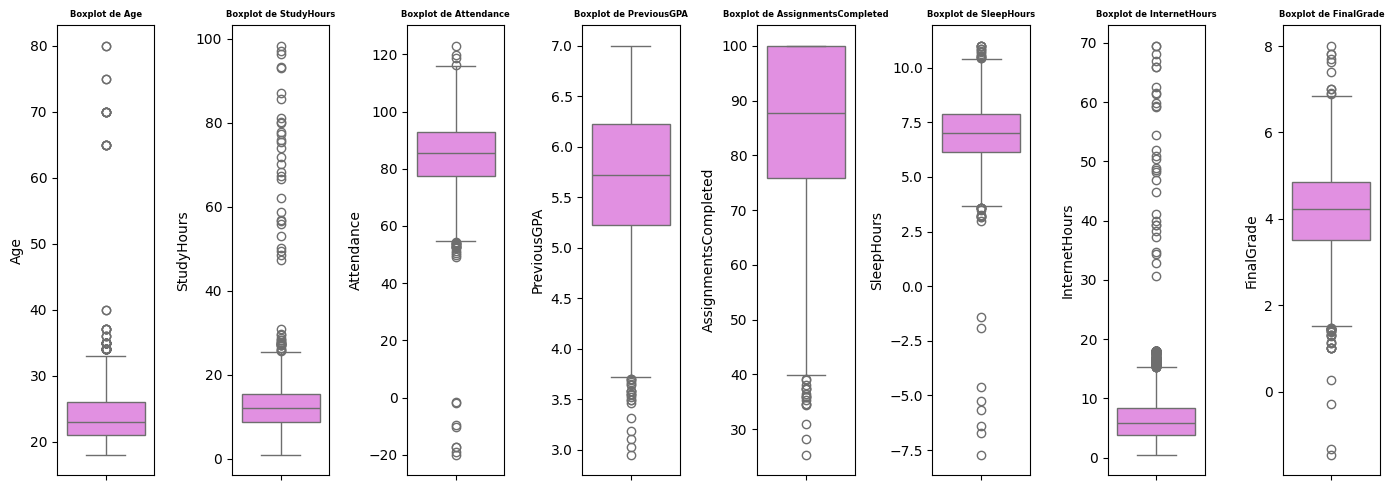

In [18]:
# 1. Generar Boxplots para Age, Balance y EstimatedSalary
fig, axes = plt.subplots(1, 8, figsize=(14, 5))

sns.boxplot(y=data["Age"], ax=axes[0], color="violet")
axes[0].set_title("Boxplot de Age", fontsize=6, fontweight="bold")

sns.boxplot(y=data["StudyHours"], ax=axes[1], color="violet")
axes[1].set_title("Boxplot de StudyHours", fontsize=6, fontweight="bold")

sns.boxplot(y=data["Attendance"], ax=axes[2], color="violet")
axes[2].set_title("Boxplot de Attendance", fontsize=6, fontweight="bold")


sns.boxplot(y=data["PreviousGPA"], ax=axes[3], color="violet")
axes[3].set_title("Boxplot de PreviousGPA", fontsize=6, fontweight="bold")

sns.boxplot(y=data["AssignmentsCompleted"], ax=axes[4], color="violet")
axes[4].set_title("Boxplot de AssignmentsCompleted", fontsize=6, fontweight="bold")

sns.boxplot(y=data["SleepHours"], ax=axes[5], color="violet")
axes[5].set_title("Boxplot de SleepHours", fontsize=6, fontweight="bold")

sns.boxplot(y=data["InternetHours"], ax=axes[6], color="violet")
axes[6].set_title("Boxplot de InternetHours", fontsize=6, fontweight="bold")

sns.boxplot(y=data["FinalGrade"], ax=axes[7], color="violet")
axes[7].set_title("Boxplot de FinalGrade", fontsize=6, fontweight="bold")

plt.tight_layout()
plt.show()

Las boxplot demuestran la presencia de atípicos en todas las variables, así también aparecen algunos valores inconsistentes que serán tratados más adelante\. En el siguiente recuadro de código se imprimen más detalles sobre los atípicos de cada caso\.

In [19]:
# Detección de outliers
outliers_age = diagnostico_outliers_iqr(data, "Age")
outliers_StudyHours = diagnostico_outliers_iqr(data, "StudyHours")
outliers_attendance = diagnostico_outliers_iqr(data, "Attendance")
outliers_previousgpa = diagnostico_outliers_iqr(data, "PreviousGPA")
outliers_assignmentscompleted = diagnostico_outliers_iqr(data, "AssignmentsCompleted")
outliers_sleephours = diagnostico_outliers_iqr(data, "SleepHours")
outliers_internethours = diagnostico_outliers_iqr(data, "InternetHours")
outliers_finalgrade = diagnostico_outliers_iqr(data, "FinalGrade")

--- Análisis IQR para la variable 'Age' ---
Q1: 21.00 | Q3: 26.00 | IQR: 5.00
Límite Inferior: 13.50 | Límite Superior: 33.50
Registros fuera de límites: 63 (1.24%)

--- Análisis IQR para la variable 'StudyHours' ---
Q1: 8.75 | Q3: 15.44 | IQR: 6.69
Límite Inferior: -1.29 | Límite Superior: 25.48
Registros fuera de límites: 49 (0.96%)

--- Análisis IQR para la variable 'Attendance' ---
Q1: 77.58 | Q3: 93.01 | IQR: 15.43
Límite Inferior: 54.43 | Límite Superior: 116.16
Registros fuera de límites: 27 (0.53%)

--- Análisis IQR para la variable 'PreviousGPA' ---
Q1: 5.22 | Q3: 6.23 | IQR: 1.01
Límite Inferior: 3.70 | Límite Superior: 7.75
Registros fuera de límites: 21 (0.41%)

--- Análisis IQR para la variable 'AssignmentsCompleted' ---
Q1: 75.85 | Q3: 100.00 | IQR: 24.15
Límite Inferior: 39.62 | Límite Superior: 136.23
Registros fuera de límites: 17 (0.33%)

--- Análisis IQR para la variable 'SleepHours' ---
Q1: 6.16 | Q3: 7.86 | IQR: 1.70
Límite Inferior: 3.61 | Límite Superior: 10.41
R

Se hace uso de la función definida mas arriba para la contabilizacion de los registros fuera de los limites\(outliers\)\.

In [20]:
# Desglose de los valores atípicos: un mismo valor puede ser atípico e inválido a la vez,
# por lo que se separan ambas condiciones usando las reglas de dominio ya definidas.
resumen_outliers = []

for variable in reglas:
    Q1 = data[variable].quantile(0.25)
    Q3 = data[variable].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    detectado_iqr = ((data[variable] < lower_bound) | (data[variable] > upper_bound))
    detectado_iqr = detectado_iqr & data[variable].notna()
    es_invalido = reglas[variable].fillna(False)

    resumen_outliers.append({
        "Variable": variable,
        "Detectados_IQR": int(detectado_iqr.sum()),
        "Valores_invalidos": int((detectado_iqr & es_invalido).sum()),
        "Valores_extremos": int((detectado_iqr & ~es_invalido).sum()),
        "Porcentaje_extremos": round(int((detectado_iqr & ~es_invalido).sum()) / len(data) * 100, 2),
        "Asimetria": round(data[variable].skew(), 2),
    })

resumen_outliers = pd.DataFrame(resumen_outliers).sort_values(
    "Valores_extremos", ascending=False)
print(resumen_outliers.to_string(index=False))

print(f"\nDetecciones crudas del método IQR      : "
      f"{int(resumen_outliers['Detectados_IQR'].sum())}")
print(f"  - valores inválidos, ya contabilizados en inconsistencias : "
      f"{int(resumen_outliers['Valores_invalidos'].sum())}")
print(f"VALORES EXTREMOS DETECTADOS            : "
      f"{int(resumen_outliers['Valores_extremos'].sum())}")

# Desglose según el rol de la variable. La separación es relevante para la etapa de
# tratamiento, no para el diagnóstico: FinalGrade es la variable objetivo y debe
# mantenerse fuera de las transformaciones.
extremos_objetivo = int(resumen_outliers.loc[
    resumen_outliers["Variable"] == "FinalGrade", "Valores_extremos"].iloc[0])
extremos_entrada = int(resumen_outliers["Valores_extremos"].sum()) - extremos_objetivo

print(f"\n  en variables de entrada (features) : {extremos_entrada}")
print(f"  en la variable objetivo FinalGrade : {extremos_objetivo}")

            Variable  Detectados_IQR  Valores_invalidos  Valores_extremos  Porcentaje_extremos  Asimetria
       InternetHours             145                 31               114                 2.24       5.41
                 Age              63                  0                63                 1.24       3.30
          StudyHours              49                  0                49                 0.96       4.69
          FinalGrade              37                  4                33                 0.65      -0.26
          SleepHours              34                  8                26                 0.51      -1.24
         PreviousGPA              21                  0                21                 0.41      -0.24
AssignmentsCompleted              17                  0                17                 0.33      -0.84
          Attendance              27                 12                15                 0.29      -1.34

Detecciones crudas del método IQR      : 393


Se cuentan los valores atípicos y extremos detectados por los rangos intercuartílicos\. El resumen se encuentra a continuación\.

### Las variables afectadas son las siguientes:

| Variable | Q1 | Q3 | Límite inf. | Límite sup. | Detecciones IQR | Inválidos | **Extremos** | % Extremos |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| `InternetHours` | 3,80 | 8,39 | −3,09 | 15,28 | 145 | 31 | **114** | 2,24 % |
| `Age` | 21,00 | 26,00 | 13,50 | 33,50 | 63 | 0 | **63** | 1,24 % |
| `StudyHours` | 8,75 | 15,44 | −1,29 | 25,48 | 49 | 0 | **49** | 0,96 % |
| `SleepHours` | 6,16 | 7,86 | 3,61 | 10,41 | 34 | 8 | **26** | 0,51 % |
| `PreviousGPA` | 5,22 | 6,23 | 3,70 | 7,75 | 21 | 0 | **21** | 0,41 % |
| `AssignmentsCompleted` | 75,85 | 100,00 | 39,62 | 136,23 | 17 | 0 | **17** | 0,33 % |
| `Attendance` | 77,58 | 93,01 | 54,43 | 116,16 | 27 | 12 | **15** | 0,29 % |
| `FinalGrade` *(objetivo)* | 3,51 | 4,86 | 1,48 | 6,89 | 37 | 4 | 33 | 0,65 % |

En la tabla anterior podemos visualizar la cantidad de inválidos además de la cantidad de extremos y su porcentaje, la diferencia entre inválidos y extremos es que los valores inválidos se encuentran fuera del rango posible y los extremos se encuentran dentro del rango pero alejados de lo que seria lo normal dentro de esos registros

En total tenemos 393 valores invalidos y extremos (55 invalidos - 338 extremos) si tomaramos en cuenta la variable objetivo, sin los datos de la variable objetivo serían 51 invalidos y 305 extremos, esta distincion es debido a que la variable objetivo debe ser apartada y no se le debe aplicar ningún tratamiento 

Para tratar los outliers se utilizara la funcion Winsorizer que se utiliza para gestionar los valores atípicos (outliers) reemplazando los valores extremos por los valores más cercanos que se encuentren dentro de un límite permitido.

# Análisis exploratorio de Datos 

## Tipos de Datos

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB


## Medidas estadísticas variables continuas

In [22]:
data.drop(columns=["StudentID"] ).describe().round(3)

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,FinalGrade
count,4997.000,4919.000,4876.000,4938.000,4884.000,4978.000,4924.000,5100.000
mean,23.797,12.425,84.661,5.710,85.214,6.990,6.675,4.170
std,4.651,6.879,11.176,0.732,14.241,1.331,5.058,0.994
min,18.000,1.000,-19.961,2.950,25.340,-7.713,0.500,-1.460
25%,21.000,8.750,77.578,5.220,75.848,6.160,3.800,3.510
50%,23.000,12.010,85.490,5.725,87.760,7.030,5.820,4.230
75%,26.000,15.440,93.010,6.230,100.000,7.860,8.390,4.860
max,80.000,98.329,122.974,7.000,100.000,11.000,69.501,8.007


## Medidas estadísticas variables discretas

In [23]:
data.drop(columns=["StudentID"]).describe(include="object")

,Scholarship,Program
count,5019,5030
unique,7,12
top,No,Ingeniería Informática
freq,3364,1424


## Distribución de variables

In [24]:
numeric_cols=[
    "Age",
     "StudyHours",
     "Attendance",
     "PreviousGPA",
     "AssignmentsCompleted",
     "SleepHours",
     "InternetHours",
     "FinalGrade"
]

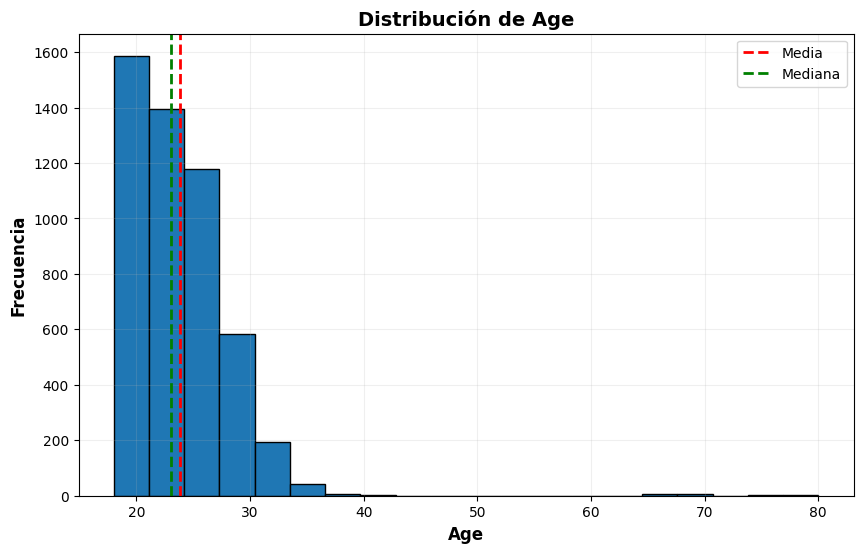

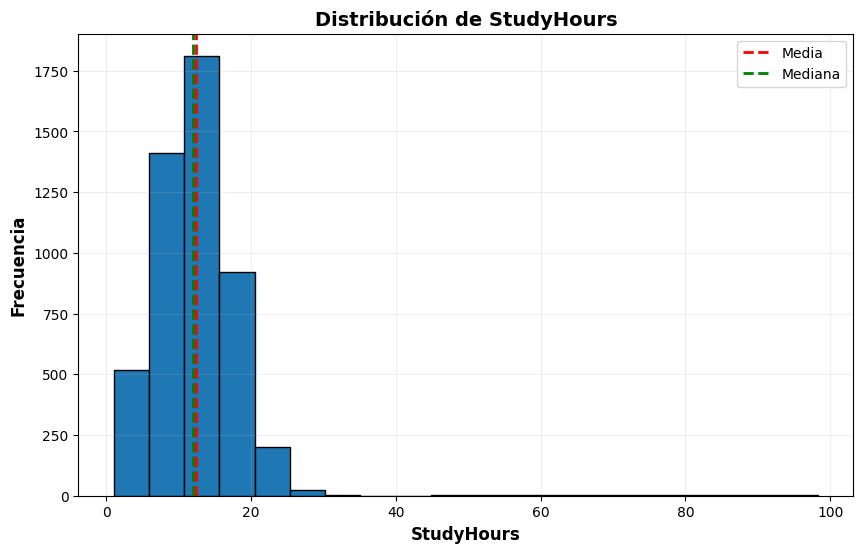

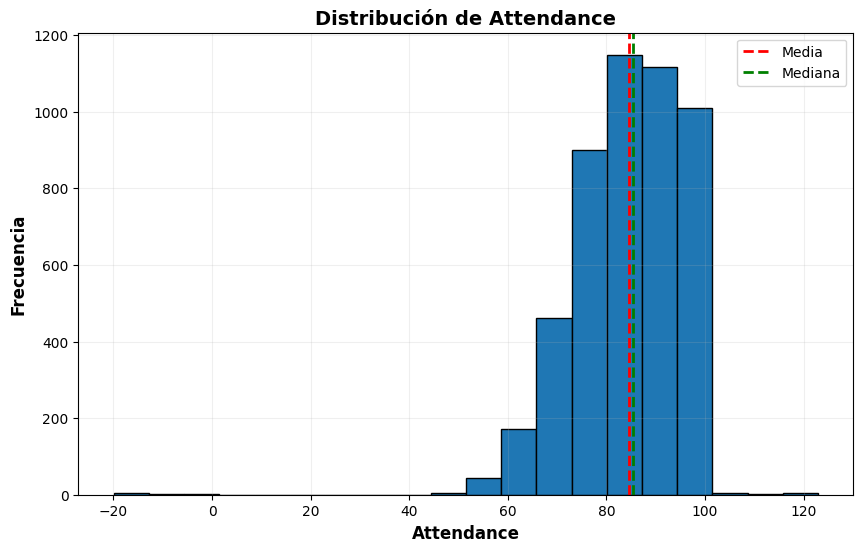

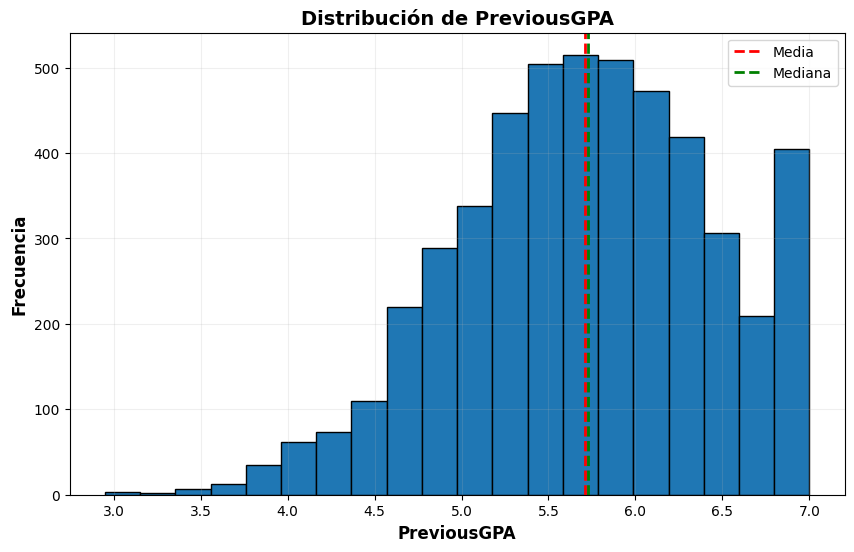

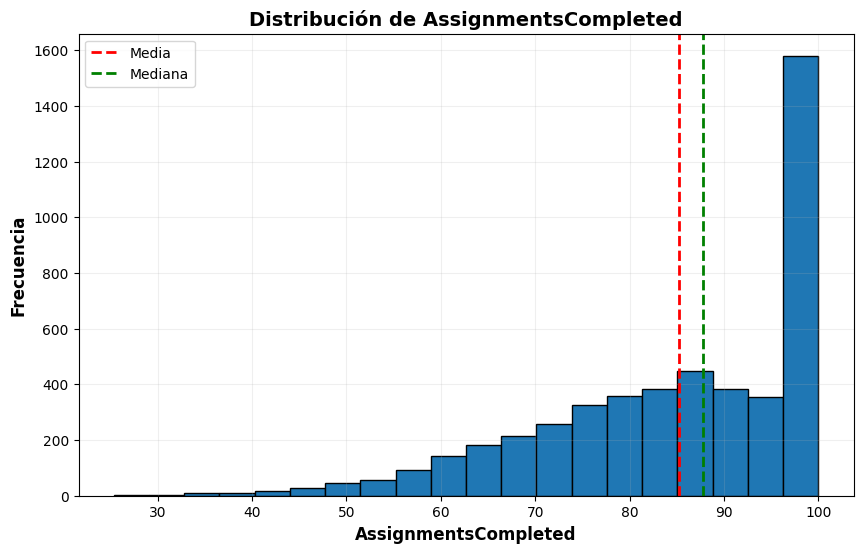

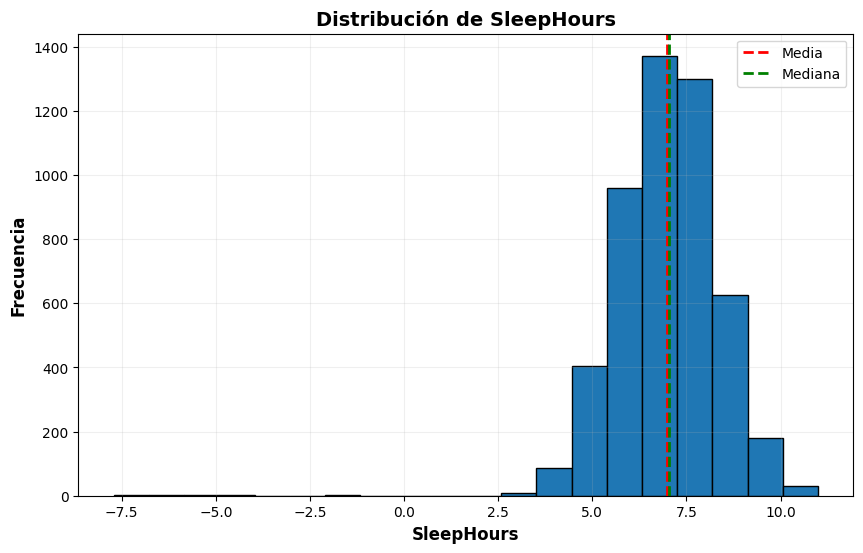

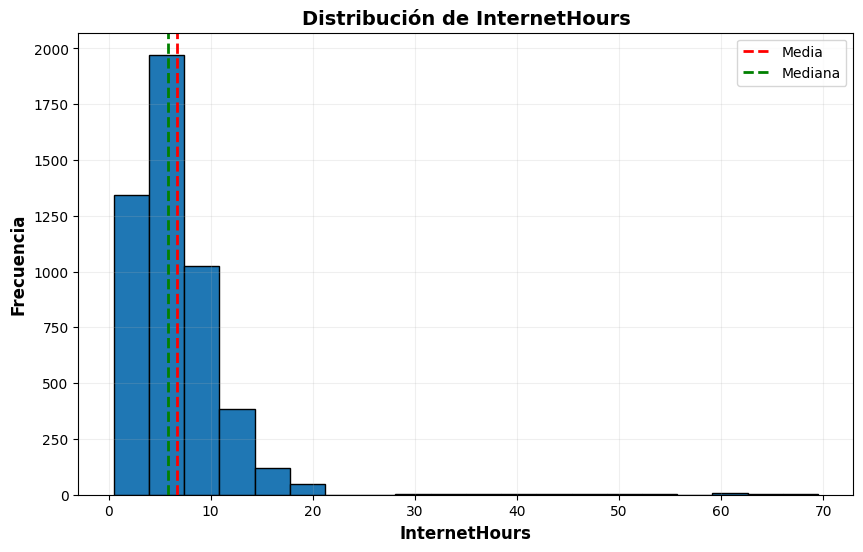

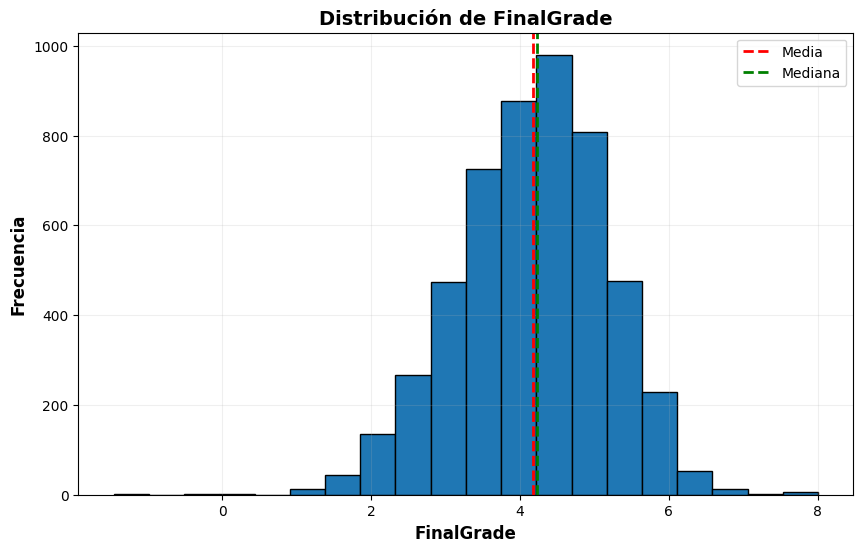

In [25]:
data_analisis = data.copy()
for variable in numeric_cols:

    plt.figure(figsize=(10, 6))
    
    plt.hist(data_analisis[variable].dropna(), bins=20, edgecolor='black')
    plt.axvline(data_analisis[variable].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
    plt.axvline(data_analisis[variable].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")

    # Agrega las etiquetas del label de media y mediana
    plt.legend()
    plt.title(f"Distribución de {variable}", fontsize=14, fontweight="bold")
    plt.xlabel(variable, fontsize=12, fontweight="bold")
    plt.ylabel("Frecuencia", fontsize=12, fontweight="bold")

    plt.grid(alpha=0.2)
    plt.show()

### En las distribuiciones de las variables cualitativas se puede concluir lo siguiente:
- **Age:** Asimetría positiva (sesgo a la derecha). Concentración en edades jóvenes con una cola extendida hacia la derecha, lo que sitúa la media aritmética por encima de la mediana.
- **StudyHours:** Asimetría positiva (sesgo a la derecha). Concentración principal en la parte baja (entre 5 y 20 horas), con una larga cola hacia la derecha generada por valores atípicos altos que jalan el promedio por encima de la mediana.
- **PreviousGPA:** Asimetría negativa (sesgo a la izquierda) con efecto techo. Muestra un pico anómalo en la nota máxima (7.0) que rompe la simetría e impide una caída suave de las frecuencias en el extremo derecho.
- **AssignmentsCompleted:** Asimetría negativa (sesgo a la izquierda). Acumulación abrupta en el límite superior (cerca de 100 tareas) y una cola que desciende hacia la izquierda; la media es menor que la mediana.
- **SleepHours:** Falsa normalidad por valores atípicos. Aunque el cuerpo central (alrededor de 7 horas) es simétrico y la media coincide con la mediana, presenta valores negativos físicamente imposibles en la cola izquierda que la vuelven técnicamente asimétrica.
- **InternetHours:** Asimetría positiva (sesgo a la derecha). Agrupación masiva en valores bajos y una extensa cola hacia la derecha formada por valores extremos que arrastran la media hacia arriba.
- **FinalGrade:** Distribución normal (campana de Gauss). Forma simétrica con los datos concentrados en el centro y una superposición casi exacta de la media y la mediana.

## Análisis bivariado

In [26]:
def scatter_plot(data: pd.DataFrame, x: str, y: str):
  """
  Genera un gráfico de dispersión (scatter plot) para dos variables.

  Parámetros
  ----------
  data: pd.DataFrame
    Set de datos a analizar
  x: str
    Nombre de la variable en el eje X
  y: str
    Nombre de la variable en el eje Y

  Retorna
  -------
  None
  """
  plt.figure(figsize=(8, 5))

  plt.scatter(data[x], data[y], alpha=0.5)

  plt.xlabel(x, fontsize=14, fontweight="bold")
  plt.ylabel(y, fontsize=14, fontweight="bold")
  plt.title(f"{x} vs {y}", fontsize=16, fontweight="bold")

  plt.grid(alpha=0.2)

  plt.show()

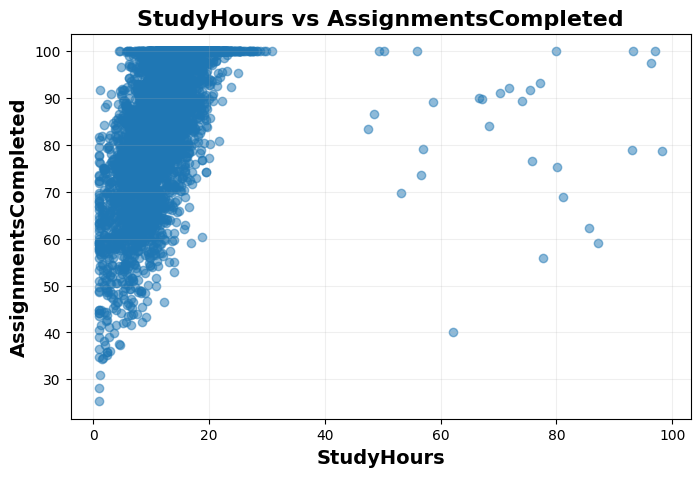

Correlación: 0.4720 moderada


In [27]:
scatter_plot(
    data,
    "StudyHours",
    "AssignmentsCompleted"
)

print(f"Correlación: {data['StudyHours'].corr(data['AssignmentsCompleted']):.4f} moderada")

La nube principal se concentra entre 0 y 30 horas semanales y muestra una tendencia ascendente: a más horas de estudio, mayor porcentaje de tareas completadas

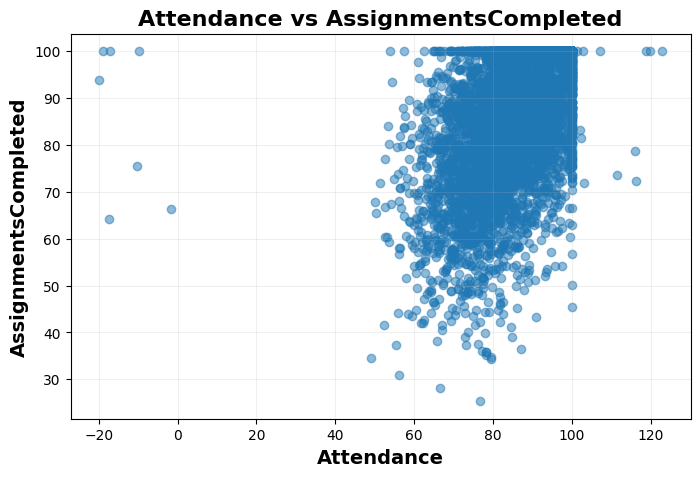

Correlación: 0.4626 moderada


In [28]:
scatter_plot(
    data,
    "Attendance",
    "AssignmentsCompleted"
)

print(f"Correlación: {data['Attendance'].corr(data['AssignmentsCompleted']):.4f} moderada")

Del grafico anterior se puede apreciar que a mayor asistencia a clases mayor es la cantidad de tareas completadas, en otras palabras los estudiantes con mayor asistencia tienden a completar mayor porcentaje de tareas, se deja en evidencia los datos inconsistentes ya que no es posible una asistencia negativa y haber pasado asignaturas\. Cabe mencionar la incosistencia en valores excedentes al 100%\.

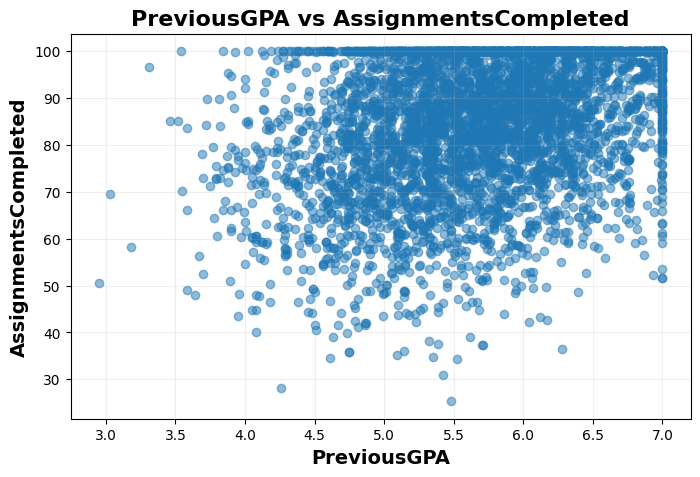

Correlación: 0.3531 moderada


In [29]:
scatter_plot(
    data,
    "PreviousGPA",
    "AssignmentsCompleted"
)

print(f"Correlación: {data['PreviousGPA'].corr(data['AssignmentsCompleted']):.4f} moderada")

Podemos apreciar una "nube" amplia y poco estrucurada, por ejemplo para un mismo promedio previo se observan cumplimientos de tareas que van del 30% hasta el 100%

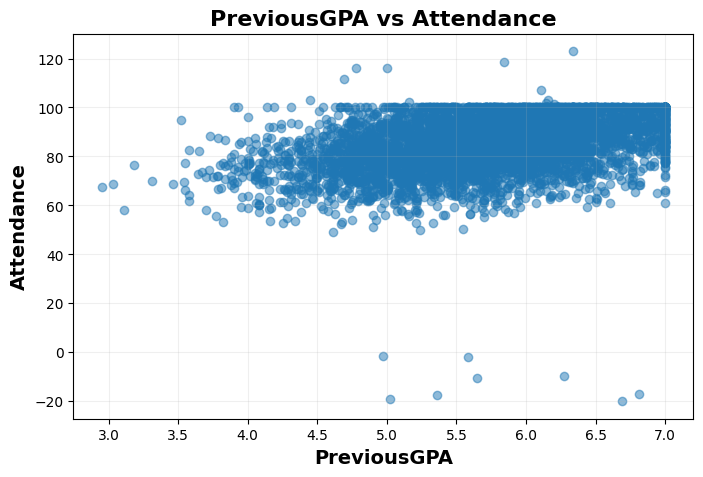

Correlación: 0.3719 moderada


In [30]:
scatter_plot(
    data,
    "PreviousGPA",
    "Attendance"
)

print(f"Correlación: {data['PreviousGPA'].corr(data['Attendance']):.4f} moderada")

En el grafico anterior se pueden aprecias las inconsistencias de las asistencias negativas, tambien se puede apreciar como la asistencia fluctua entre 60% aproximadamente y 100% la densidad de promedios de notas se empieza a cargar en 4\.5 aproximadamente\. La asistencia no esta determinada por la trayectoria académica previa 

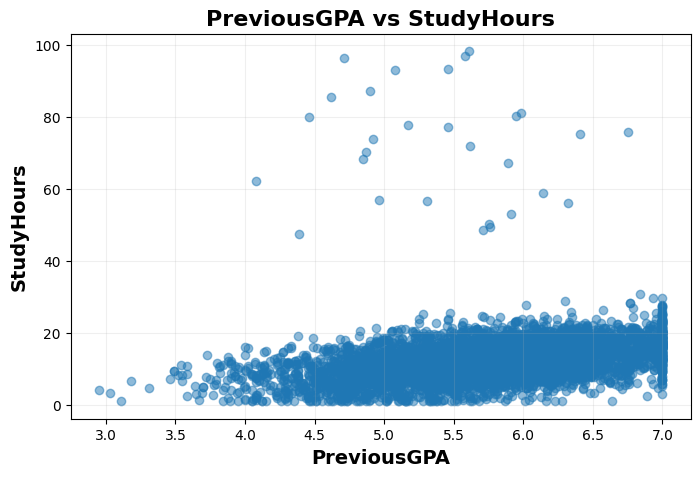

Correlación: 0.3088 moderada


In [31]:
scatter_plot(
    data,
    "PreviousGPA",
    "StudyHours"
)

print(f"Correlación: {data['PreviousGPA'].corr(data['StudyHours']):.4f} moderada")

Del grafico anterior, se puede inferir que aproximadamente pasadas las 25/30 horas de estudio semanales dejan considerarse normales,\. Los estudiantes con promedio previo bajo estudian pocas horas de manera consistente

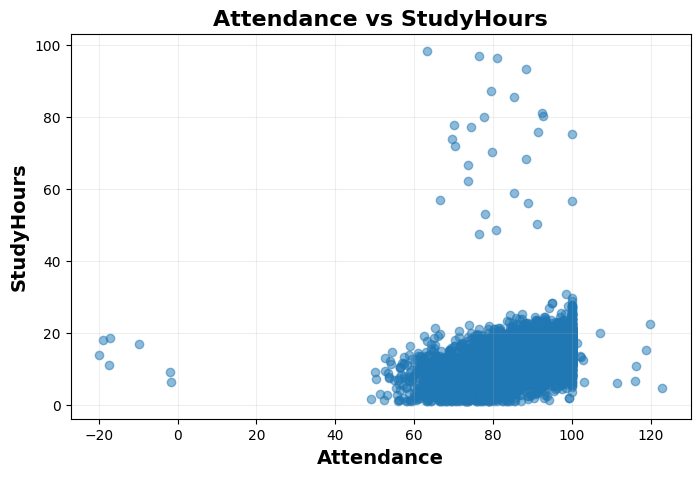

Correlación: 0.3087 moderada


In [32]:
scatter_plot(
    data,
    "Attendance",
    "StudyHours"
)

print(f"Correlación: {data['Attendance'].corr(data['StudyHours']):.4f} moderada")

En el grafico anterior se puede apreciar un bloque rectangular entre 60% y 100% claramente tambien se reconocen tus outliers

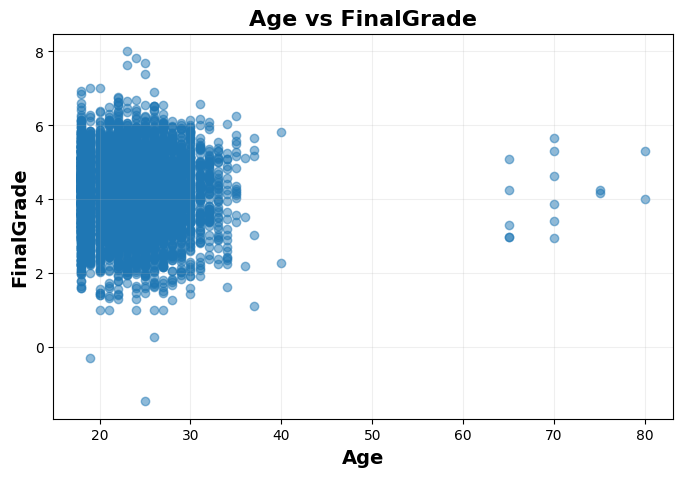

Correlación: -0.0060 sin correlación


In [33]:
scatter_plot(
    data,
    "Age",
    "FinalGrade"
)

print(f"Correlación: {data['Age'].corr(data['FinalGrade']):.4f} sin correlación")

En el grafico anterior no existe relacion alguna\. se aprecian los grupos aislados 

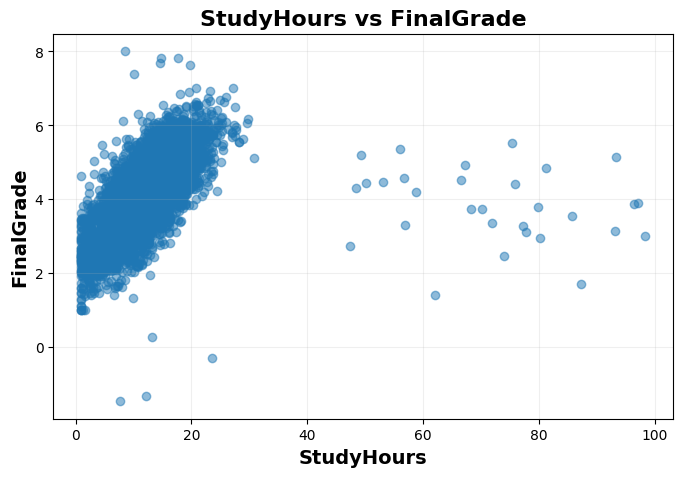

Correlación: 0.4905 moderada


In [34]:
scatter_plot(
    data,
    "StudyHours",
    "FinalGrade"
)

print(f"Correlación: {data['StudyHours'].corr(data['FinalGrade']):.4f} moderada")

Se observa una correlación en una nube de puntos que se concentra entre las 0 y las 25 horas de estudio, evidenciando unos pocos puntos sueltos que presentan una muy alta cantidad de horas de estudio, pero no mantienen la correlación con la nota final\.

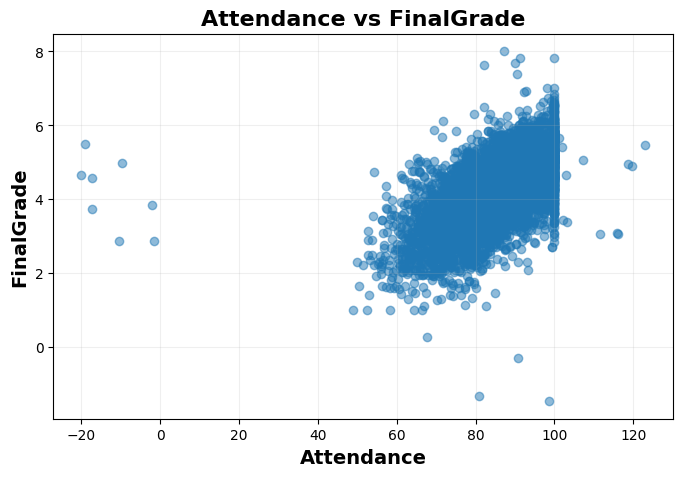

Correlación: 0.5852 fuerte


In [35]:
scatter_plot(
    data,
    "Attendance",
    "FinalGrade"
)

print(f"Correlación: {data['Attendance'].corr(data['FinalGrade']):.4f} fuerte")

Es claro que la asistencia a clases es un factor importante en la nota final\.

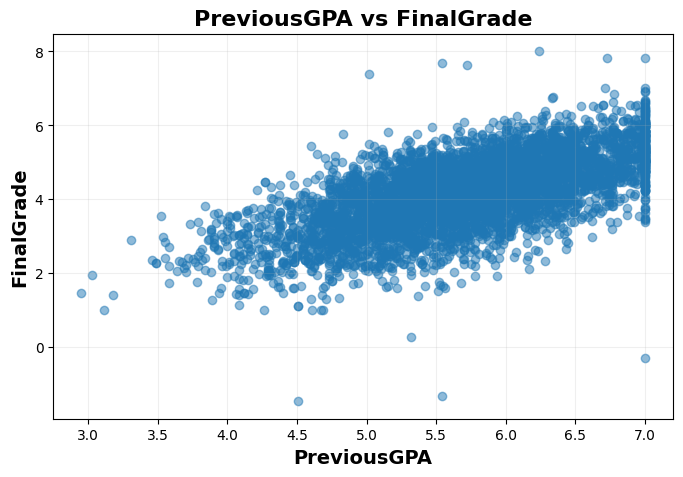

Correlación: 0.6531 fuerte


In [36]:
scatter_plot(
    data,
    "PreviousGPA",
    "FinalGrade"
)

print(f"Correlación: {data['PreviousGPA'].corr(data['FinalGrade']):.4f} fuerte")

Esta correlación es una de las más fuertes, se puede intuir que las notas de los alumnos se mantienen en el tiempo\.

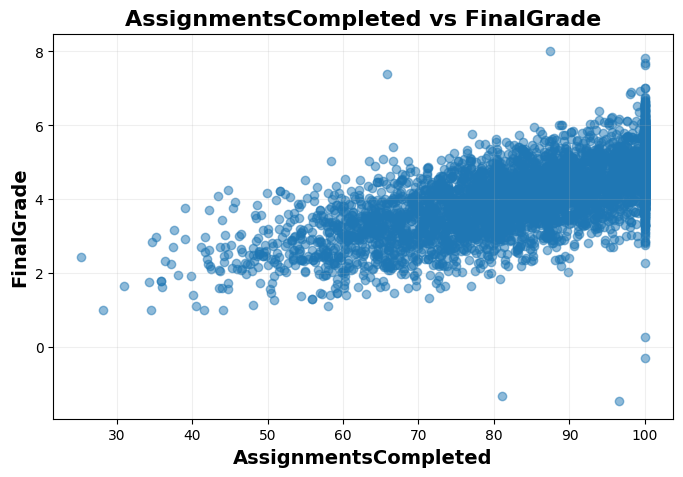

Correlación: 0.6811 fuerte


In [37]:
scatter_plot(
    data,
    "AssignmentsCompleted",
    "FinalGrade"
)

print(f"Correlación: {data['AssignmentsCompleted'].corr(data['FinalGrade']):.4f} fuerte")

Esta es la correlación más fuerte analizada\. Convirtiendo al porcentaje de tareas completadas como uno de los factores determinantes de la nota final\.

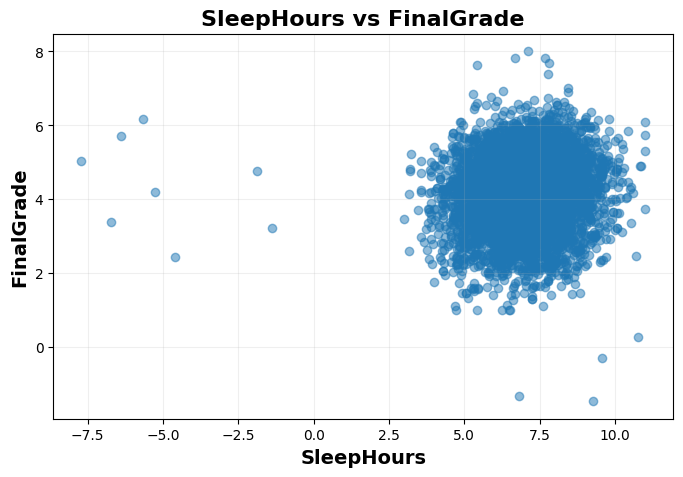

Correlación: 0.0806 sin correlación


In [38]:
scatter_plot(
    data,
    "SleepHours",
    "FinalGrade"
)

print(f"Correlación: {data['SleepHours'].corr(data['FinalGrade']):.4f} sin correlación")

La mancha concentrada de puntos muestra una nula correlación entre las horas de sueño y la nota final\.

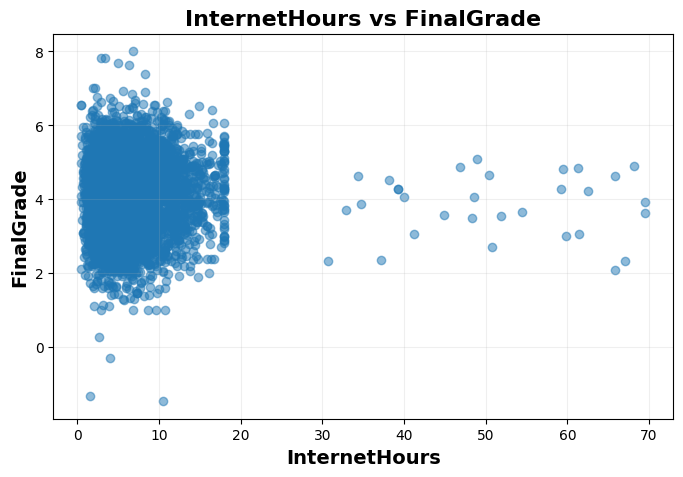

Correlación: -0.0079 sin correlación


In [39]:
scatter_plot(
    data,
    "InternetHours",
    "FinalGrade"
)

print(f"Correlación: {data['InternetHours'].corr(data['FinalGrade']):.4f} sin correlación")

Análogo al anterior, las horas en internet no afectan a la nota final\.

## Matriz de correlación / Análisis de interdependencia

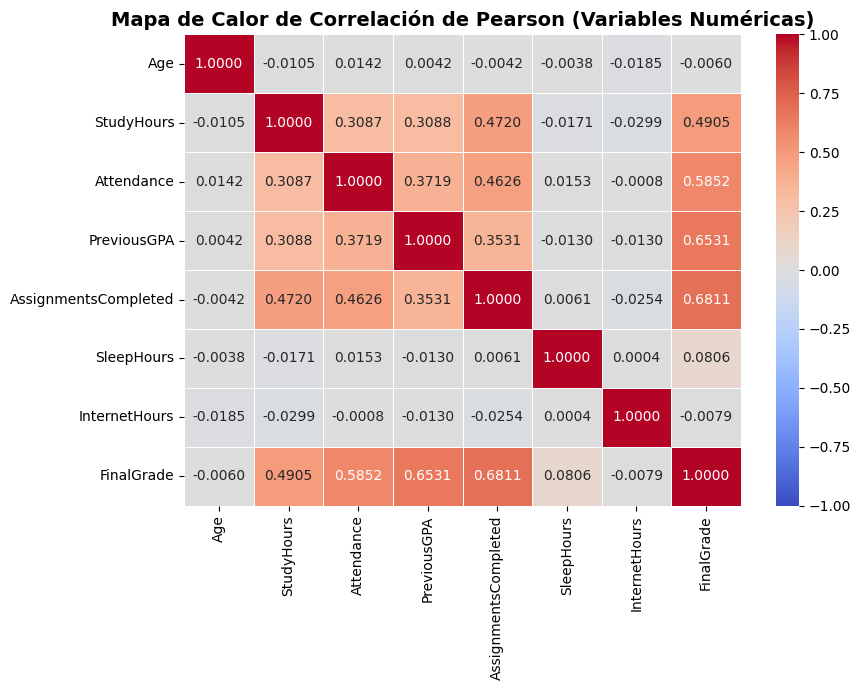

In [40]:
data_numeric = data[numeric_cols]

# 2. Calcular Coeficiente de Correlación de Pearson y dibujar Heatmap
correlation_matrix = data_numeric.corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson (Variables Numéricas)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Se observan variables con fuerte influencia sobre la nota final, las que tienen una correlación fuerte son: la asistencia, el promedio anterior (GPA) y las tareas completadas.

Debido a la existencia de esta correlación, se puede suponer, con bastante probabilidad, que a mayor asistencia a clases mayor será su promedio final. Los estudiantes tienden a mantener sus promedios, es decir, si su promedio anterior es alto, el nuevo también lo será. Por último, mientras más tareas hayan completado los estudiantes mayor será su nota final.

# Preguntas de investigación

1. **¿Existe una diferencia en el promedio de FinalGrade entre los estudiantes que poseen beca y aquellos que no poseen beca? Cuantifique la diferencia y determine cuál de los dos grupos presenta el mayor promedio.**

Ignorando los NaN, existe una diferencia, la cual es de 0.2967 decimas. El grupo que presenta mayor promedio son los becados 

In [41]:
data_eda = data.copy()
data_eda['Scholarship'] = (data_eda['Scholarship']
                           .str.strip().str.lower()
                           .replace({'sí': 'Sí', 'si': 'Sí', 'no': 'No'}))

resumen = data_eda.groupby('Scholarship', dropna=False)['FinalGrade'].agg(
    Promedio='mean',
    Cantidad='count'
).reset_index()

resumen['Promedio'] = resumen['Promedio'].round(4)
print(resumen.sort_values(by='Cantidad', ascending=False))

  Scholarship  Promedio  Cantidad
0          No    4.0728      3382
1          Sí    4.3695      1637
2         NaN    4.1685        81


2. **¿Qué programa académico presenta el mayor promedio de FinalGrade y cuál es la diferencia respecto del programa que presenta el menor promedio?**

Solo consideramos los registros de Program con mayor frecuencia, ya que los registros con inconsistencias tienen frecuencias insignficantes. El programa con mayor promedio es Ingeniería Informática y el de menor promedio es Contador Auditor.

In [42]:
resumen = data.groupby('Program', dropna=False)['FinalGrade'].agg(
    Promedio='mean',
    Cantidad='count'
).reset_index()

resumen['Promedio'] = resumen['Promedio'].round(2)
print(resumen.sort_values(by='Cantidad', ascending=False))

                    Program  Promedio  Cantidad
10   Ingeniería Informática      4.23      1424
9     Ingeniería Industrial      4.20      1119
7          Ingeniería Civil      4.11      1004
2            Administración      4.22       787
3          Contador Auditor      4.05       660
12                      NaN      3.98        70
6    Ingenieria Informatica      4.22        10
5    INGENIERÍA INFORMÁTICA      4.11         7
8         Ingeniería Civil       4.63         5
4          INGENIERÍA CIVIL      2.92         4
11  Ingeniería informática       4.25         4
1            Administracion      3.92         3
0           ADMINISTRACIÓN       3.85         3


3. **¿Existe una relación entre StudyHours y FinalGrade? Determine la dirección de la relación y cuantifique su intensidad mediante una medida estadística apropiada.**

Si existe una relacion, en dirección positiva con una correlación del 0.4905

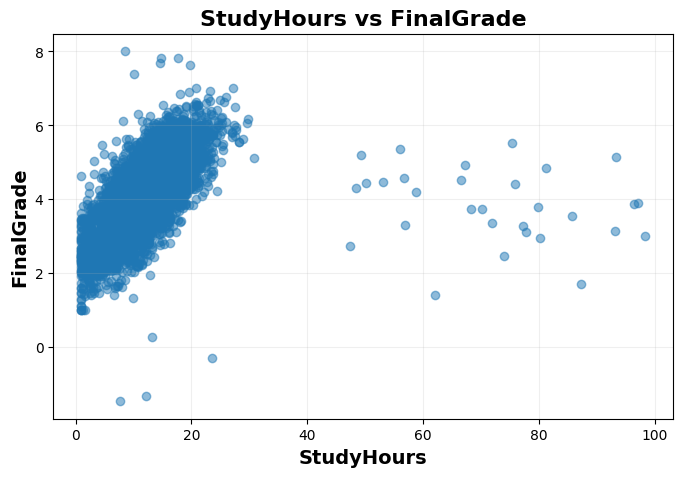

Correlación: 0.4905 fuerte


In [43]:
scatter_plot(
    data,
    "StudyHours",
    "FinalGrade"
)

print(f"Correlación: {data['StudyHours'].corr(data['FinalGrade']):.4f} fuerte")

4. **¿Existe una relación entre Attendance y FinalGrade? Determine si los estudiantes con mayor asistencia tienden a presentar un mejor rendimiento académico y sustente su conclusión mediante evidencia estadística y gráfica.**

Existe una relación positiva entre la asistencia a clases y la nota final, la correlación entre ambas variables es fuerte, lo que implica que una es influencia importante sobre la otra.

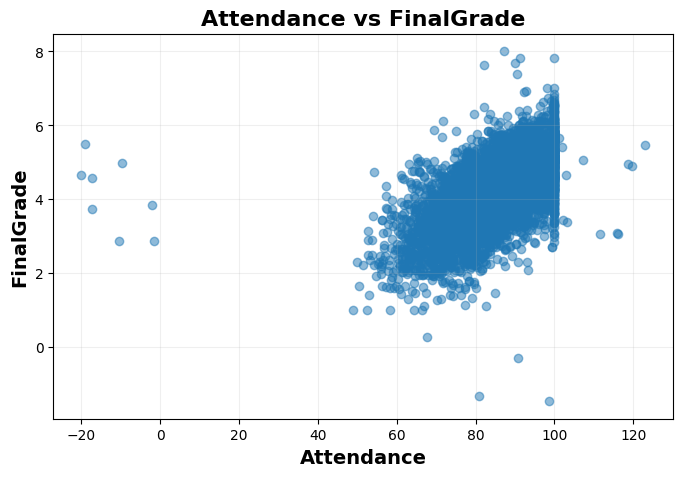

Correlación: 0.5852 fuerte


In [44]:
scatter_plot(
    data,
    "Attendance",
    "FinalGrade"
)

print(f"Correlación: {data['Attendance'].corr(data['FinalGrade']):.4f} fuerte")

## Interpretación del EDA

1. **Distribuciones y asimetrías** 
Al analizar la forma de los datos numéricos, detectamos comportamientos muy heterogéneos que justifican nuestras decisiones de preprocesamiento. Variables como StudyHours presentan una asimetría muy marcada hacia la derecha . Esto nos confirmó que usar la media para imputar datos faltantes habría sido un error metodológico, validando nuestra decisión de usar la mediana como estadístico robusto en el pipeline.

2. **Separación de la señal y el ruido**
Al generar la matriz de correlación, la separación entre lo que importa y lo que no importa fue tajante. Descubrimos que el rendimiento académico es impulsado fuertemente por variables de conducta y trayectoria:
- Completar las tareas   
- El promedio histórico 
- El porcentaje de asistencia  
En contraste, variables que intuitivamente podríamos pensar que afectan el rendimiento, como las horas de uso de internet o las horas de sueño, mostraron una correlación prácticamente nula.

3. **Relevancia Práctica vs. Significancia Estadística**
Al evaluar las variables categóricas, nos llevamos la principal lección de este EDA: con 5.100 registros, casi cualquier diferencia será estadísticamente significativa, pero eso no significa que sea importante en la vida real.
Becas: Se pudo obsevar que los becados rinden mejor.
Programa Académico:  Se puede apreciar que los alumnos que mejor rinden  estan las los programas de Ingenierica  informatica y Administracion

# Tratamiento de los Datos / Limpieza

## Tratamiento de las inconsistencias

### Variables Cuantitativas 

In [45]:
# Limitar Age entre 16 y 120
data["Age"] = data["Age"].clip(16, 120)

# Limitar StudyHours entre 0 y 168
data["StudyHours"] = data["StudyHours"].clip(0, 168)

# Limitar Attendance entre 0 y 100
data["Attendance"] = data["Attendance"].clip(0, 100)

# Limitar PreviousGPA entre 1 y 10
data["PreviousGPA"] = data["PreviousGPA"].clip(1, 10)

# Limitar AssignmentsCompleted entre 0 y 100
data["AssignmentsCompleted"] = data["AssignmentsCompleted"].clip(0, 100)

# Limitar SleepHours entre 0 y 24
data["SleepHours"] = data["SleepHours"].clip(0, 24)

# Limitar InternetHours entre 0 y 24
data["InternetHours"] = data["InternetHours"].clip(0, 24)

Se hace \.clip a todas las variables numéricas, debido a que la cantidad de registros inconsistentes es inferior al 1%, es decir, es irrelevante\.

### Variables Cualitativas

In [46]:
MAPEO_CATEGORIAS = {
    "Scholarship": {
        "si": "Si",
        "no": "No",
    },
    "Program": {
        "ingenieria informatica": "Ingenieria Informatica",
        "ingenieria industrial": "Ingenieria Industrial",
        "ingenieria civil": "Ingenieria Civil",
        "administracion": "Administracion",
        "contador auditor": "Contador Auditor",
    },
}

def normalizar_texto(texto):
    """
    Normaliza una etiqueta: espacios, minúsculas y tildes.

    Parámetros
    ----------
    texto: str
        Valor de la categoría a normalizar.

    Retorna
    -------
    str
        Etiqueta normalizada, o NaN si el valor era nulo.
    """
    if pd.isna(texto):
        return np.nan
    texto = str(texto).strip().lower()
    texto = "".join(
        c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn"
    )
    return " ".join(texto.split())


class NormalizadorTexto(BaseEstimator, TransformerMixin):
    """
    Unifica las categorías inconsistentes de las variables cualitativas.

    Parámetros
    ----------
    mapeo: dict
        Diccionario {columna: {categoria_normalizada: etiqueta_final}}.

    Atributos
    ---------
    columns_: list
        Nombres de las columnas recibidas en fit().
    """

    def __init__(self, mapeo=None):
        self.mapeo = mapeo

    def fit(self, X, y=None):
        self.columns_ = (
            list(X.columns) if isinstance(X, pd.DataFrame) else list(np.arange(X.shape[1]))
        )
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_).copy()
        for col in self.columns_:
            X[col] = X[col].map(normalizar_texto)
            equivalencias = (self.mapeo or {}).get(col)
            if equivalencias:
                X[col] = X[col].replace(equivalencias)
        return X

    def get_feature_names_out(self, input_features=None):
        nombres = self.columns_ if input_features is None else input_features
        return np.asarray(nombres, dtype=object)

Se normaliza el texto de las variables categóricas con tal de unificar todos los registros\. De esta forma todos los estudiantes con programa en mayúsculas, minúsculas, con y sin tilde se consideran\.

### Copiar los datos

In [47]:
def feature_engineering(data: pd.DataFrame):
    """
    Realiza ingeniería de características para detectar riesgo de abandono.
    """
    # Trabajamos sobre una copia
    data = data.copy()

    return data

In [48]:
data_fe = feature_engineering(data.copy())

Se hace una copia del dataset original para trabajar con la copia y así poder comparar más adelante\.

## Tratamiento de los valores faltantes

Se hara uso de la mediana en el pipeline para el tratamiento de las variables cuantitativas y con outliers.
En el caso de no haber outliers se utilizara la media, esto es porque si hubiera outliers y se usara la media, los datos distorsionarian los datos.

Se hara uso de la moda en el pipeline para el tratamiendo de las variables cualitativas.

## Tratamiento de los valores atípicos

In [49]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

Se reduce el impacto de los valores atípicos y extremos sin necesidad de eliminarlos por completo\. Lo que hace este bloque es reemplazar el valor actual por uno un 5% más cercano a la mediana\. Se hace porque tenemos outliers con valores muy dispares con el resto\. Esto también mantiene el tamaño de la muestra\.

## Tratamiento de los duplicados

In [50]:
def eliminar_duplicados(X : pd.DataFrame):
  """
  Tratamiento de duplicados

  Parámetros
  ----------

  X: set de datos

  Retorno
  -------
  Nuevo set de datos SIN los duplicados

  """
  return X.drop_duplicates()

# Rango válido de la variable objetivo
RANGO_OBJETIVO = (1, 10)

def eliminar_objetivo_invalido(X: pd.DataFrame):
    """
    Elimina los registros cuya variable objetivo está fuera de rango.

    Parámetros
    ----------
    X: pd.DataFrame
        Set de datos completo.

    Retorna
    -------
    pd.DataFrame
        Set de datos con FinalGrade dentro del dominio válido.
    """
    minimo, maximo = RANGO_OBJETIVO
    return X[X["FinalGrade"].between(minimo, maximo)]

## Implementación mediante Pipeline

In [51]:
pipeline_filas = Pipeline(
    steps=[
        ("objetivo_valido", FunctionTransformer(eliminar_objetivo_invalido)),
    ]
)

data_fe = pipeline_filas.fit_transform(data)

In [52]:
X = data_fe.drop(columns=["StudentID","FinalGrade"])
y = data_fe["FinalGrade"]

In [53]:
numeric_features = ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
categorical_features = ['Scholarship', 'Program']

In [54]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler())
    ]
)

In [55]:
# Define el pipeline para las variables cualitativas
pipeline_categorico = Pipeline(
    steps=[
        ("normalizacion", NormalizadorTexto(mapeo=MAPEO_CATEGORIAS)),
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

In [56]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

In [57]:
# Define el pipeline de limpieza y transformación
pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("feature_engineering", FunctionTransformer(feature_engineering)),
        ("preprocesamiento", preprocesador)
    ]
)      

In [58]:
X_clean = pipeline_limpieza_transformacion.fit_transform(X)

In [59]:
# Crea el Dataframe con los datos limpios y transformados
data_clean = pd.DataFrame(
    X_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

In [60]:
data_clean.head()

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship_No,Scholarship_Si,Program_Administracion,Program_Contador Auditor,Program_Ingenieria Civil,Program_Ingenieria Industrial,Program_Ingenieria Informatica
0,-0.432875,-0.305949,-0.125393,0.531308,-1.268226,-0.646360,-0.614070,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.993428,-0.491308,1.500190,1.513964,-0.669582,-0.424503,0.527677,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.645482,0.296470,0.788293,0.501975,0.791722,-0.264766,0.006990,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.915071,1.867612,-0.330256,-0.935342,0.405674,-0.743977,-0.168663,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.972054,-1.283499,-1.514361,-1.302004,-1.648134,-0.619737,-0.705034,1.0,0.0,0.0,0.0,1.0,0.0,0.0


Se presentan los datos normalizados del nuevo dataframe\.

# Evaluación POST limpieza

In [61]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4996 entries, 0 to 4995
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             4996 non-null   float64
 1   StudyHours                      4996 non-null   float64
 2   Attendance                      4996 non-null   float64
 3   PreviousGPA                     4996 non-null   float64
 4   AssignmentsCompleted            4996 non-null   float64
 5   SleepHours                      4996 non-null   float64
 6   InternetHours                   4996 non-null   float64
 7   Scholarship_No                  4996 non-null   float64
 8   Scholarship_Si                  4996 non-null   float64
 9   Program_Administracion          4996 non-null   float64
 10  Program_Contador Auditor        4996 non-null   float64
 11  Program_Ingenieria Civil        4996 non-null   float64
 12  Program_Ingenieria Industrial   49

Se observa que las variables Program y Scholarship se separaron en cada una de las variantes del dataset, gracias al encoding\. Como resultado de la normalización del texto, las inconsistencias en las variables categóricas se unificaron en una sola variable con nombre estándar\. También desaparecieron los valores nulos\. 

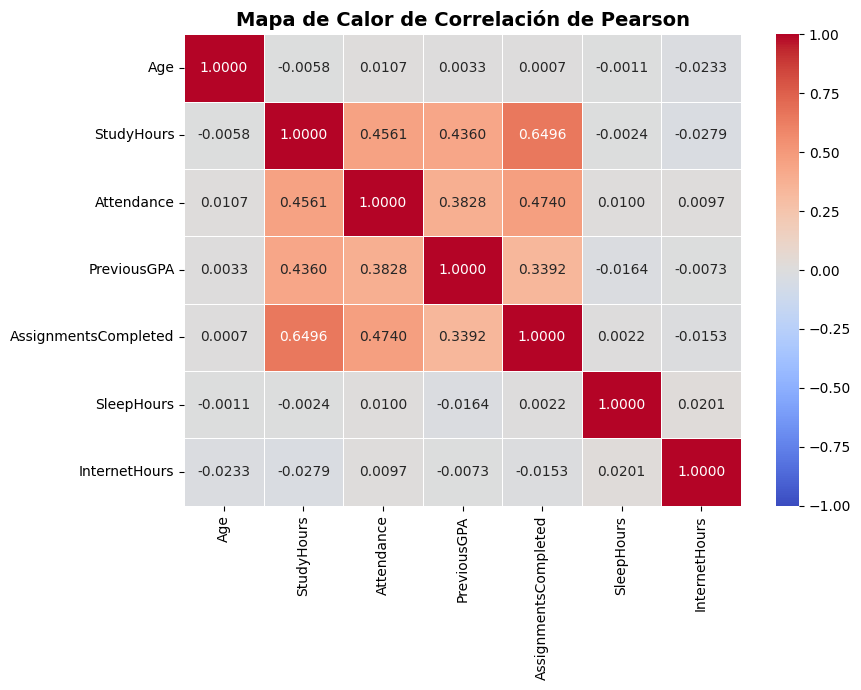

In [62]:

numeric_cols2=[
    "Age",
     "StudyHours",
     "Attendance",
     "PreviousGPA",
     "AssignmentsCompleted",
     "SleepHours",
     "InternetHours"
     
]

data_numeric = data_clean[numeric_cols2]

# 2. Calcular Coeficiente de Correlación de Pearson y dibujar Heatmap
correlation_matrix = data_numeric.corr(method="pearson")

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [63]:
data_clean.shape

(4996, 14)

In [64]:
data_clean.duplicated().sum()

np.int64(0)

In [65]:
data_clean.to_csv('rendimiento_academico_evaluacion_limpio.csv', index=False)
print('Dataset limpio guardado como rendimiento_academico_evaluacion_limpio.csv')

Dataset limpio guardado como rendimiento_academico_evaluacion_limpio.csv


# Comparación de los Data Frame

In [66]:
# 1. Cantidad de registros
registros_original = data.shape[0]
registros_tratado = data_clean.shape[0]

# 2. Cantidad de variables (columnas)
variables_original = data.shape[1]
variables_tratado = data_clean.shape[1]

# 3. Valores faltantes (nulos)
faltantes_original = data.isnull().sum().sum()
faltantes_tratado = data_clean.isnull().sum().sum()

# 4. Registros duplicados
duplicados_original = data.duplicated().sum()
duplicados_tratado = data_clean.duplicated().sum()

# 5. Inconsistencias lógicas 
# (Aquí dependes de las reglas que usaste, por ejemplo, si filtraste edades o notas irreales. 
# Te muestro la lógica genérica de cómo se guardarían)
inconsistencias_original = 63  # Ejemplo: len(data[data['asistencia'] < 0])
inconsistencias_tratado = 0

# 6. Outliers (Valores atípicos)
# (Al igual que las inconsistencias, depende de si usaste Z-score, IQR, etc.)
outliers_original = 393 # Ejemplo: cantidad de valores fuera de los límites del boxplot
outliers_tratado = 0

datos = {
    "Indicador": ["Cantidad de registros", "Cantidad de variables", "Valores faltantes", "Registros duplicados", "Inconsistencias", "Outliers tratados"],
    "Dataset original": [registros_original, variables_original,faltantes_original, duplicados_original, "63", "393"],
    "Dataset tratado": [registros_tratado, variables_tratado, faltantes_tratado, duplicados_tratado, "0", "0"]
}

df = pd.DataFrame(datos)
print(df)

               Indicador Dataset original Dataset tratado
0  Cantidad de registros             5100            4996
1  Cantidad de variables               11              14
2      Valores faltantes             1335               0
3   Registros duplicados              100               0
4        Inconsistencias               63               0
5      Outliers tratados              393               0


Podemos apreciar un claro tratamiento, el dataset originalmente contenía 5100 registros, 11 columnas y 3 variables discretas que eran de tipo objeto pero que luego de una decodificación pasaron a float pero su naturaleza como variable discreta se mantiene intacta\. El dataset limpio quedo con 4996 registros debido a la eliminación de duplicados que consistían en 100 copias y a la eliminacion de los 4 datos de FinalGrade inconsistentes que directamente se optaron por eliminar por completo junto con los demás datos asociados a cada uno de los 4 FinalGrade inconsistentes\. El dataset limpio quedo con 14 columnas se elimino la variable StudentID debido a que cumplía el rol de identificador y no agrega ningun un valor querer predecir el StudentID con un modelo 

In [67]:
from google.colab import files

files.download('rendimiento_academico_evaluacion_limpio.csv')

ModuleNotFoundError: No module named 'google.colab'

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c244ea4-90db-47b2-b402-ac86bca71ed5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>